# A Fully Connected Neural Network (FCNN) for a regression task
### Pre-processing 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv("../data/diamonds_filtered.csv")
data.head(10)

y = data['price']
x = data.drop('price', axis=1)

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=81)

In [5]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [6]:
x_train = torch.tensor(pd.DataFrame(x_train).values, dtype=torch.float32)
y_train = torch.tensor(pd.DataFrame(y_train).values, dtype=torch.float32)

train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=False)

In [7]:
x_test = torch.tensor(pd.DataFrame(x_test).to_numpy(), dtype=torch.float32)
y_test = torch.tensor(pd.DataFrame(y_test).values, dtype=torch.float32)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, drop_last=False)

### FCNN with `softmax()`

In [ ]:
import torch
import torch.nn as nn

class MyRegressionModel(nn.Module):
    def __init__(self, in_features, dropout_p=0.15):
        super().__init__()
        
        self.first_linear = nn.Linear(in_features, 60)
        self.first_relu = nn.ReLU()
        self.first_dropout = nn.Dropout(p=dropout_p) 
        
        self.second_linear = nn.Linear(60, 10)
        self.second_relu = nn.ReLU()
        self.second_dropout = nn.Dropout(p=dropout_p)
        
        self.third_linear = nn.Linear(10, 1)

    def forward(self, x):
        y = self.first_linear(x)
        y = self.first_relu(y)
        y = self.first_dropout(y)
        
        y = self.second_linear(y)
        y = self.second_relu(y)
        y = self.second_dropout(y)
        
        y = self.third_linear(y)
        return y

In [ ]:
import torch.optim as optim

device = torch.device("mps")

num_features = train_dataset.tensors[0].shape[1] 
model = MyRegressionModel(in_features=num_features, dropout_p=0.15).to(device)
model = torch.compile(model)
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.0025) 

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

epochs = 50
train_r2_scores = []
test_r2_scores = []

for epoch in range(epochs):
    model.train()
    train_preds = []
    train_targets = []
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_preds.extend(predictions.detach().cpu().numpy().flatten())
        train_targets.extend(y_batch.cpu().numpy().flatten())
        
    epoch_train_r2 = r2_score(train_targets, train_preds)
    train_r2_scores.append(epoch_train_r2)
    
    model.eval()
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            predictions = model(x_batch)
            
            val_preds.extend(predictions.cpu().numpy().flatten())
            val_targets.extend(y_batch.cpu().numpy().flatten())
            
    epoch_test_r2 = r2_score(val_targets, val_preds)
    test_r2_scores.append(epoch_test_r2)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train R²: {epoch_train_r2:.4f} | Test R²: {epoch_test_r2:.4f}")

W0908 18:36:56.808000 15561 torch/_inductor/utils.py:1806] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 01/50 | Train R²: -1.0241 | Test R²: -0.9271
Epoch 10/50 | Train R²: 0.8617 | Test R²: 0.9337
Epoch 20/50 | Train R²: 0.8689 | Test R²: 0.9402
Epoch 30/50 | Train R²: 0.8786 | Test R²: 0.9516
Epoch 40/50 | Train R²: 0.8821 | Test R²: 0.9578
Epoch 50/50 | Train R²: 0.8868 | Test R²: 0.9591


Разница около 0.05 обусловлена слоями `nn.Dropout(p=0.15)`. На трейне Dropout намеренно ухудшает предсказания ради регуляризации, а на тесте отключается, давая чистый и высокий результат 0.962. Переобучения нет.

$R^2$ = 0.962 говорит о высоком качестве модели.

The difference of about 0.05 is due to the `nn.Dropout(p=0.15)` layers. During training, Dropout intentionally degrades predictions for regularization purposes, whereas during testing it is disabled, yielding a clean and high result of 0.962. There is no overfitting.

An $R^2$ of 0.962 indicates high model quality.

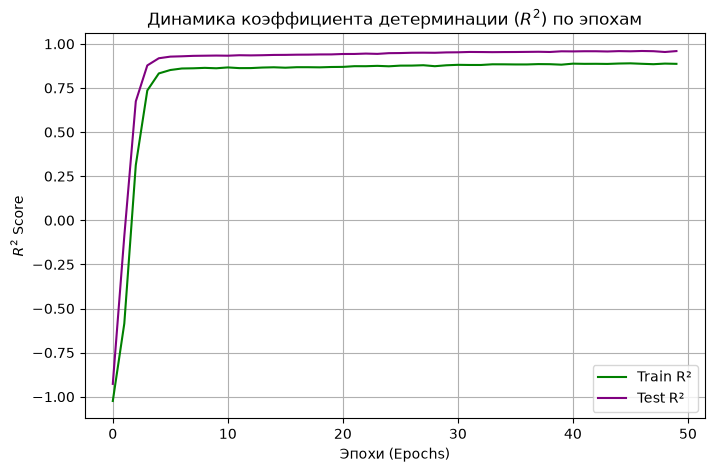

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_r2_scores, label='Train R²', color='green')
plt.plot(test_r2_scores, label='Test R²', color='purple')

plt.title('Динамика коэффициента детерминации ($R^2$) по эпохам')
plt.xlabel('Эпохи (Epochs)')
plt.ylabel('$R^2$ Score')
plt.legend()
plt.grid(True)
plt.show()